# Laplace and REML

{py:class}`liesel.optim.LaplaceLoss` integrates selected continuous parameters out
of the model's joint density, then fits the remaining parameters. Here we fit a
Poisson model's mean and random-effect scale while integrating eight group effects.

```{note}
**Relation to REML.** {class}`LaplaceLoss <liesel.optim.LaplaceLoss>` approximates integration over selected
parameters in smooth models, including non-Gaussian and nonlinear models.
The integrated parameters, priors, and Jacobians determine the target. Here
we integrate the group effects and retain parameter priors, yielding a
marginal posterior.

Classical restricted maximum likelihood (REML) is a special case: integrate
both random effects and fixed-effect coefficients in a Gaussian linear mixed
model, with flat priors on the latter and no additional prior or Jacobian terms
on the remaining parameters. Laplace integration is then exact; see
[Bates et al., Section 3.4](https://lme4.github.io/lme4/articles/lmer.pdf#page=16).
```

## Build the model

Use float64 for this example: enable it before creating arrays and pass
`to_float32=False` to the model.

In [1]:
import logging

import jax
import jax.numpy as jnp
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

logging.getLogger("liesel").setLevel(logging.WARNING)

jax.config.update("jax_enable_x64", True)

counts = jnp.array(
    [
        [1.0, 2.0, 1.0, 0.0],
        [3.0, 2.0, 4.0, 3.0],
        [6.0, 5.0, 4.0, 5.0],
        [9.0, 7.0, 10.0, 8.0],
        [13.0, 16.0, 12.0, 15.0],
        [2.0, 4.0, 3.0, 2.0],
        [5.0, 8.0, 6.0, 7.0],
        [20.0, 23.0, 19.0, 21.0],
    ],
)
group = jnp.repeat(jnp.arange(8), 4)

mu = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.Normal, 0.0, 2.0),
    name="mu",
)

tau = lsl.Var.new_param(
    0.5,
    dist=lsl.Dist(tfd.LogNormal, jnp.log(0.5), 0.7),
    bijector=tfb.Exp(),
    name="tau",
)

b = lsl.Var.new_param(
    jnp.zeros(8),
    dist=lsl.Dist(tfd.Normal, 0.0, tau),
    name="b",
)

log_rate = lsl.Var.new_calc(
    lambda mu, b: mu + b[group],
    mu,
    b,
    name="log_rate",
)

y = lsl.Var.new_obs(
    counts.ravel(),
    dist=lsl.Dist(tfd.Poisson, log_rate=log_rate),
    name="y",
)

model = lsl.Model(y, to_float32=False)

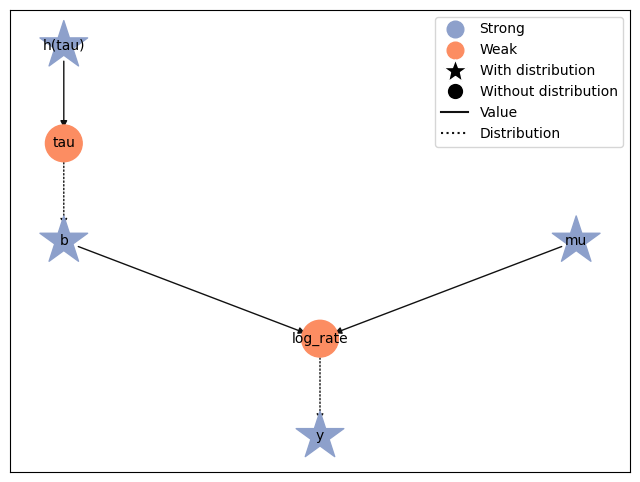

In [2]:
model.plot(width=8, height=6)

The group effects `b` enter the log rate; `tau` controls their prior scale.

## Fit the model

In [3]:
loss = opt.LaplaceLoss(model, latent=["b"])
stopper = opt.Stopper(epochs=60, patience=10, rtol=1e-10)

result = opt.LieselOptim(
    model,
    loss=loss,
    optimizers="lbfgs",
    loss_monitor="train_full_data",
    stopper=stopper,
    show_progress=False,
).fit()

In [4]:
result.status

'early_stopping'

Use full-data batches and `"train_full_data"` monitoring. The outer parameters
are `mu` and `h(tau)`; `b` keeps its prior. The unscaled loss includes priors,
Jacobians, and normalization constants; see {doc}`optimizer-loss-scaling`.

For observed arrays with different lengths, pass an explicit `split` to
{class}`LaplaceLoss <liesel.optim.LaplaceLoss>`; {ref}`check the groups and opt in <optimizer-split-groups>` first.

## Inspect group effects

The fit retains the group effects at their conditional mode, together with the
outer parameters that produced them. Recover both from the best recorded fit:

In [5]:
outer = result.position_min_monitor
state = result.loss_state_min_monitor
b_mode = state.latent_position["b"]

In [6]:
pd.DataFrame(
    {"estimate": [float(outer["mu"]), float(outer["h(tau)"])]},
    index=["mu", "log(tau)"],
).round(3)

,estimate
mu,1.679
log(tau),-0.229


In [7]:
pd.DataFrame(
    {"conditional_mode": b_mode},
    index=range(1, 9),
).rename_axis("group").round(3)

,conditional_mode
group,
1,-1.272
2,-0.514
3,-0.064
4,0.441
5,0.934
6,-0.586
7,0.182
8,1.328


Each effect multiplies the baseline rate `exp(mu)` by `exp(b)`.
For the first group, the multiplier is about `exp(-1.272) = 0.28`;
for the last group, it is about `exp(1.328) = 3.77`.

For the final snapshot, pair {attr}`position_final <liesel.optim.OptimResult.position_final>` with {attr}`loss_state_final <liesel.optim.OptimResult.loss_state_final>`.
See {py:class}`~liesel.optim.LaplaceState` for convergence diagnostics, parameter
ordering, and the saved curvature in {attr}`latent_precision_cholesky <liesel.optim.LaplaceState.latent_precision_cholesky>`.

## Estimate uncertainty

Turn the completed fit into a joint Gaussian approximation for `mu`, `h(tau)`,
and all eight group effects. It includes their correlations, so each draw is a
complete parameter set that can be passed directly to {meth}`Model.predict <liesel.model.Model.predict>`:

In [8]:
posterior = loss.approximate_joint_posterior(result)
draws = posterior.sample(1000, seed=jax.random.key(42))

predicted = model.predict(draws, predict=["tau", "log_rate"])
tau_draws = predicted["tau"]
rate_draws = jnp.exp(predicted["log_rate"])
quantiles = jnp.array([0.05, 0.5, 0.95])

{meth}`Model.predict <liesel.model.Model.predict>` transforms draws back to the positive `tau` scale and evaluates
the log rates. The leading axis indexes the 1,000 draws; the last log-rate
axis indexes observations. Exponentiate each draw before taking rate summaries,
rather than exponentiating an average log rate. For example, summarize the
between-group scale with its 5th, 50th, and 95th percentiles:

In [9]:
pd.DataFrame(
    {"tau": jnp.quantile(tau_draws, quantiles)},
    index=["5%", "50%", "95%"],
).round(3)

,tau
5%,0.516
50%,0.787
95%,1.194


The approximate posterior median is 0.79, with a 90% credible interval of
0.52 to 1.19. The same draws give intervals for each group's expected count:

In [10]:
# Four observations share each group's rate.
group_rates = rate_draws[:, ::4]
lower, median, upper = jnp.quantile(group_rates, quantiles, axis=0)
rate_summary = pd.DataFrame(
    {
        "group": range(1, 9),
        "median": median,
        "lower": lower,
        "upper": upper,
        "observed": counts.mean(axis=1),
    },
)

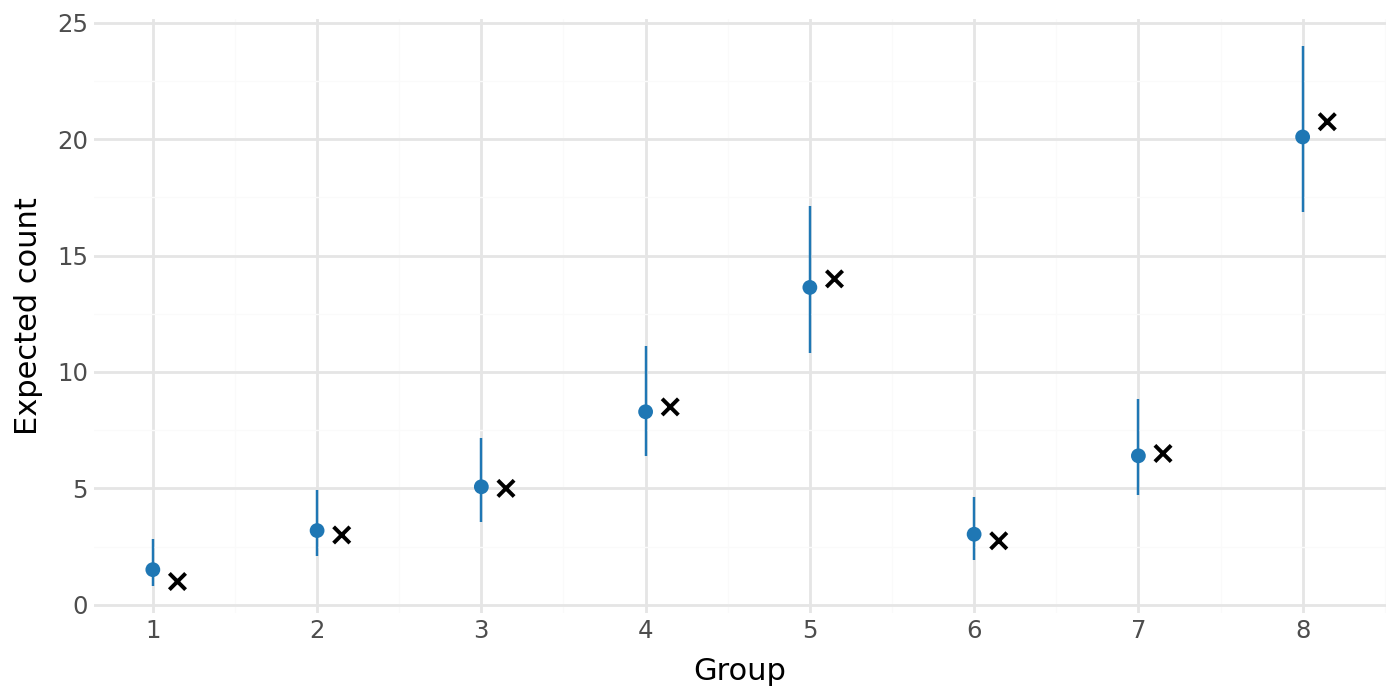

In [11]:
(
    p9.ggplot(rate_summary, p9.aes(x="group", y="median"))
    + p9.geom_pointrange(
        p9.aes(ymin="lower", ymax="upper"),
        color="#1f77b4",
    )
    + p9.geom_point(
        p9.aes(y="observed"),
        shape="x",
        color="black",
        size=2.5,
        stroke=0.8,
        position=p9.position_nudge(x=0.15),
    )
    + p9.scale_x_continuous(breaks=range(1, 9))
    + p9.labs(x="Group", y="Expected count")
    + p9.theme_minimal()
    + p9.theme(figure_size=(7, 3.5))
)

Blue points and bars show posterior medians and 90% credible intervals;
black crosses mark observed means, shifted slightly to the right for clarity.
The intervals carry uncertainty in the mean, scale, and group effects through
to expected counts. New observations also vary according to the Poisson
distribution.

For matrix calculations, {meth}`posterior.covariance() <liesel.optim.LaplaceApproximation.covariance>` constructs the full covariance
on request. {attr}`posterior.names <liesel.optim.LaplaceApproximation.names>` and {attr}`posterior.shapes <liesel.optim.LaplaceApproximation.shapes>` describe its ordering.

To work with one parameter, request its block by name:

In [12]:
b_covariance = posterior.marginal_covariance_blocks(["b"])["b"]

In [13]:
pd.DataFrame(b_covariance, index=range(1, 9), columns=range(1, 9)).round(3)

,1,2,3,4,5,6,7,8
1,0.195,0.059,0.058,0.059,0.060,0.059,0.059,0.060
2,0.059,0.137,0.070,0.072,0.074,0.067,0.071,0.074
3,0.058,0.070,0.120,0.077,0.078,0.069,0.076,0.079
4,0.059,0.072,0.077,0.108,0.081,0.071,0.078,0.082
5,0.060,0.074,0.078,0.081,0.101,0.073,0.080,0.084
6,0.059,0.067,0.069,0.071,0.073,0.140,0.071,0.073
7,0.059,0.071,0.076,0.078,0.080,0.071,0.114,0.081
8,0.060,0.074,0.079,0.082,0.084,0.073,0.081,0.096


This 8 × 8 matrix is the marginal covariance of `b`; it includes the
uncertainty that `mu` and `h(tau)` propagate to `b`.
Omit the name selection to get a dictionary of blocks for every parameter.
For a factor of each block's inverse, use
{meth}`posterior.marginal_precision_cholesky_blocks() <liesel.optim.LaplaceApproximation.marginal_precision_cholesky_blocks>`.
For precision conditional on all the other parameters, use
{meth}`posterior.conditional_precision_blocks() <liesel.optim.LaplaceApproximation.conditional_precision_blocks>`; these are diagonal blocks of the
joint precision and generally differ from the marginal precisions.

The helper adds curvature work once per call and checks stationarity and positive
definiteness. It selects `at="min_monitor"` by default; use `at="final"` for the
final snapshot. Keep the model, data, and fixed parameters unchanged between fitting
and this call. See {py:meth}`~liesel.optim.LaplaceLoss.approximate_joint_posterior` for controls.

(optimizer-laplace-failure)=

## Inspect a failure

An insufficient inner budget makes a useful diagnostic example:

In [14]:
short_loss = opt.LaplaceLoss(model, latent=["b"], inner_max_iter=1)
failed = opt.LieselOptim(
    model,
    loss=short_loss,
    optimizers="lbfgs",
    loss_monitor="train_full_data",
    show_progress=False,
).fit()

In [15]:
failed.status

'numerical_failure'

In [16]:
failed.failure_reason

'Inner Laplace optimization failed: iteration limit.'

{attr}`failed.failed_loss_state <liesel.optim.OptimResult.failed_loss_state>` holds the inner solver diagnostics. Failures
preserve the last valid snapshot; without one, the loss state is `None`.
Failed fits cannot resume; earlier saved checkpoints remain available.

The posterior helper raises on failure by default. `raise_on_failure=False` returns
an invalid diagnostic object with available gradients, curvature, and the failure
reason:

In [17]:
diagnostic = short_loss.approximate_joint_posterior(
    failed,
    raise_on_failure=False,
)

In [18]:
diagnostic.valid

False

Its {meth}`sample <liesel.optim.LaplaceApproximation.sample>` and
{meth}`covariance <liesel.optim.LaplaceApproximation.covariance>` methods raise.

## Control warm starts

By default, each inner solve starts from the latent mode committed at the end of
the previous epoch. Set `warm_start=False` to start from the model's latent values:

In [19]:
cold_loss = opt.LaplaceLoss(model, latent=["b"], warm_start=False)

Pass `cold_loss` to a new fit to compare. Resuming an interrupted fit is a separate
operation: {doc}`optimizer-checkpointing` explains how to resume with saved states.

## Tune the inner solve

Use `inner_max_iter` to change the iteration budget and `inner_tol` to
control convergence. See {py:class}`~liesel.optim.LaplaceLoss` for their definitions
and defaults.

The solver finds a local mode; warm and cold starts can find different modes.
For d scalar latent parameters, dense curvature uses O(d²) storage and O(d³)
linear algebra.
This version targets a few hundred latents with a modest outer dimension.